# Kaggle Competition Predictive Electric Vehicle Purchases



In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((3, 4))

In [14]:
# Vamos a crear los dataframes de nuestro dataset
df = pd.read_csv('../data/train.csv')
df.head(10)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
5,5,50,95938.0,55.1,2,8,15,3.0,Other,Urban,Sedan,No,No,Low,No
6,6,55,109219.0,42.9,1,1,5,4.0,Male,Suburban,Sedan,Yes,Yes,Low,Yes
7,7,45,60796.0,52.2,2,13,3,2.0,Other,Urban,SUV,No,Yes,Medium,No
8,8,39,67725.0,31.5,2,11,3,2.0,Female,Urban,Sedan,No,Yes,Medium,No
9,9,57,114827.0,66.9,2,0,1,5.0,Male,Rural,Sedan,Yes,Yes,Low,Yes


In [ ]:
# Primero vamos a cambiar los tipos de datos que necesitemos cambiar
df[['Environmental_Concern_Level', 'Gender', 'Range_Anxiety_Level']] = df[['Environmental_Concern_Level', 'Gender', 'Range_Anxiety_Level']].astype('category')

df[['City_Type', 'Current_Car_Type']] = df[['City_Type', 'Current_Car_Type']].astype('object')

df['Home_Charging_Possible'] = df['Home_Charging_Possible'].map({"Yes": True, "No": False})
df['Subsidy_Available'] = df['Subsidy_Available'].map({"Yes": True, "No": False})
df['Will_Buy_EV'] = df['Will_Buy_EV'].map({"Yes": 1, "No": 0})

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   id                           668665 non-null  int64   
 1   Age                          668665 non-null  int64   
 2   Annual_Income_USD            668665 non-null  float64 
 3   Daily_Commute_km             668665 non-null  float64 
 4   Number_of_Cars_Owned         668665 non-null  int64   
 5   Charging_Stations_Near_Home  668665 non-null  int64   
 6   Charging_Stations_Near_Work  668665 non-null  int64   
 7   Environmental_Concern_Level  668665 non-null  category
 8   Gender                       668665 non-null  category
 9   City_Type                    668665 non-null  object  
 10  Current_Car_Type             668665 non-null  object  
 11  Home_Charging_Possible       668665 non-null  bool    
 12  Subsidy_Available            668665 non-null  bool    


In [16]:
df.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Will_Buy_EV
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.000000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,0.174645
std,193027.103211,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,0.379663
min,0.000000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,0.000000
25%,167166.000000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,0.000000
50%,334332.000000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,0.000000
75%,501498.000000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,0.000000
max,668664.000000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,1.000000


## Analisis Univariado

Vamos a revisar variable a variable como esta organizado este dataset

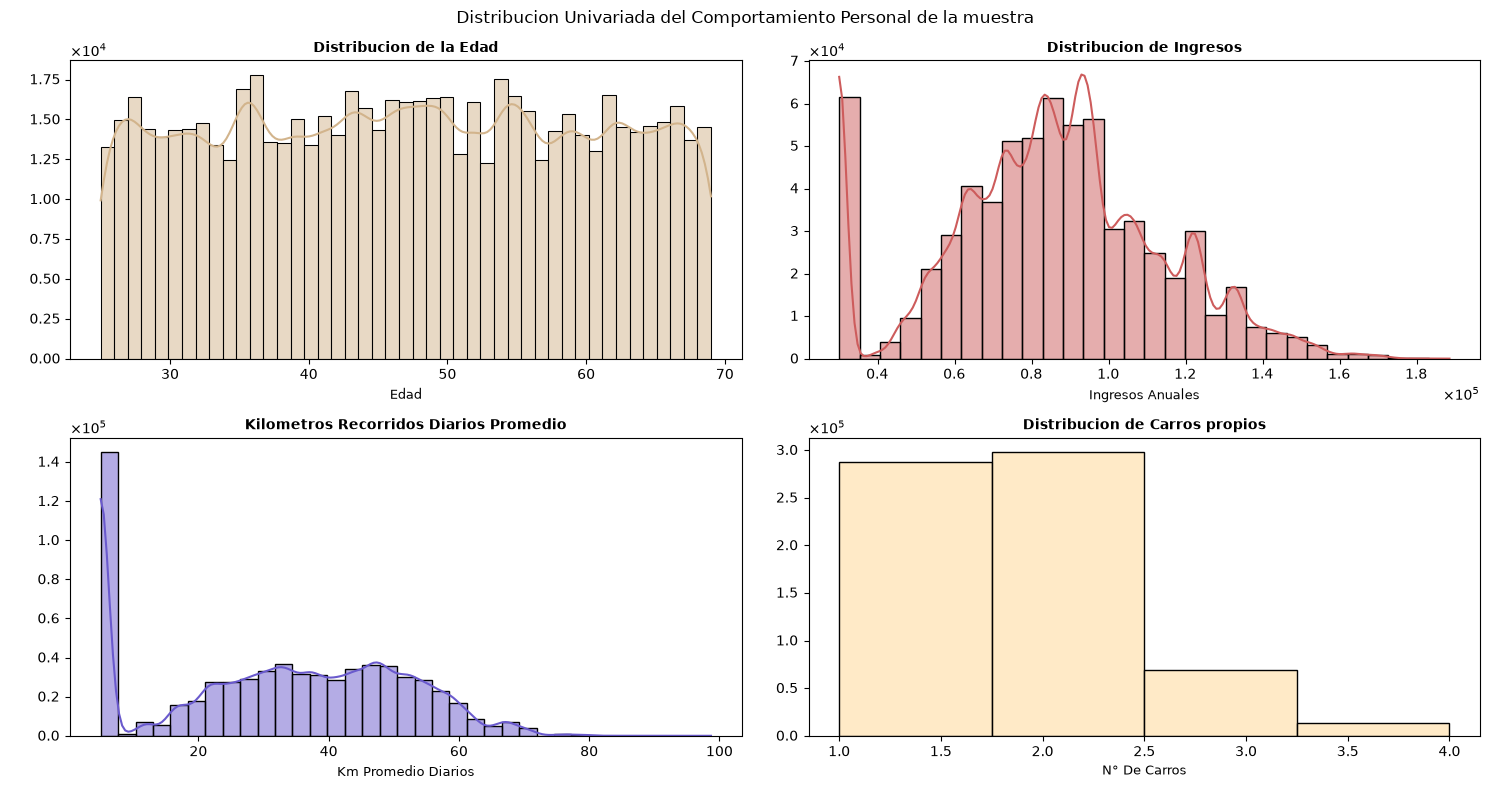

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15,8))

sns.histplot(data=df, x="Age", ax=axes[0,0], bins=45, multiple='dodge', kde=True, color='tan')
axes[0,0].yaxis.set_major_formatter(formatter)
axes[0,0].set_title("Distribucion de la Edad", fontsize=10, fontweight=700)
axes[0,0].set_ylabel(" ")
axes[0,0].set_xlabel("Edad", fontsize=9, fontweight=500)

sns.histplot(data=df, x="Annual_Income_USD", ax=axes[0,1], bins=30, kde=True, color='indianred')
axes[0,1].xaxis.set_major_formatter(formatter)
axes[0,1].yaxis.set_major_formatter(formatter)
axes[0,1].set_title("Distribucion de Ingresos", fontsize=10, fontweight=700)
axes[0,1].set_ylabel(" ")
axes[0,1].set_xlabel("Ingresos Anuales", fontsize=9, fontweight=500)

sns.histplot(data=df, x="Daily_Commute_km", ax=axes[1,0], bins=35, kde=True, color='slateblue')
axes[1,0].yaxis.set_major_formatter(formatter)
axes[1,0].set_title("Kilometros Recorridos Diarios Promedio", fontsize=10, fontweight=700)
axes[1,0].set_ylabel(" ")
axes[1,0].set_xlabel("Km Promedio Diarios", fontsize=9, fontweight=500)

sns.histplot(data=df, x="Number_of_Cars_Owned", ax=axes[1,1], bins=4, color='moccasin')
axes[1,1].yaxis.set_major_formatter(formatter)
axes[1,1].set_title("Distribucion de Carros propios", fontsize=10, fontweight=700)
axes[1,1].set_ylabel(" ")
axes[1,1].set_xlabel("N° De Carros", fontsize=9, fontweight=500)

fig.suptitle("Distribucion Univariada del Comportamiento Personal de la muestra")
plt.tight_layout()
plt.show()

In [18]:
# Edad
print(f"Las edades estan entre: {df['Age'].min()} y {df['Age'].max()}")

# Ingresos
print(f"Los ingresos anuales toman rango entre {df['Annual_Income_USD'].min()} - {df['Annual_Income_USD'].max()}")

Las edades estan entre: 25 y 69
Los ingresos anuales toman rango entre 30000.0 - 188549.0


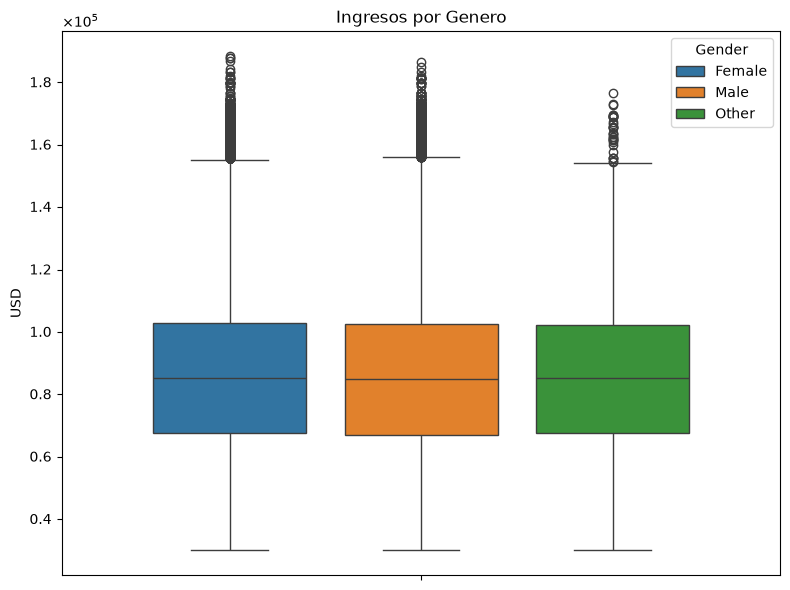

In [19]:
# Boxplot de Ingresos
plt.figure(figsize=(8,6))

sns.boxplot(y=df['Annual_Income_USD'], hue=df['Gender'], gap=0.2).yaxis.set_major_formatter(formatter)

plt.title("Ingresos por Genero")
plt.ylabel("USD")
plt.tight_layout()
plt.show()

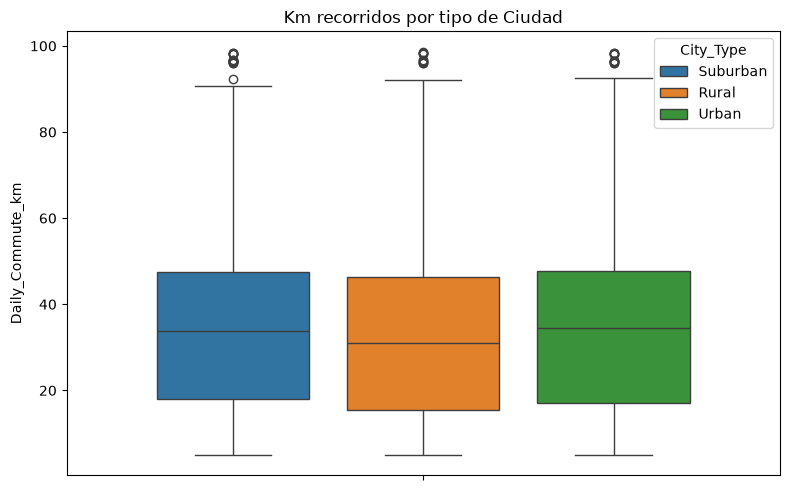

In [20]:
# Boxplot de Km recorridos diarios dependiendo del tipo de ciudad
plt.figure(figsize=(8,5))

sns.boxplot(y=df['Daily_Commute_km'], hue=df['City_Type'], gap=0.2)

plt.title("Km recorridos por tipo de Ciudad")
plt.tight_layout()
plt.show()

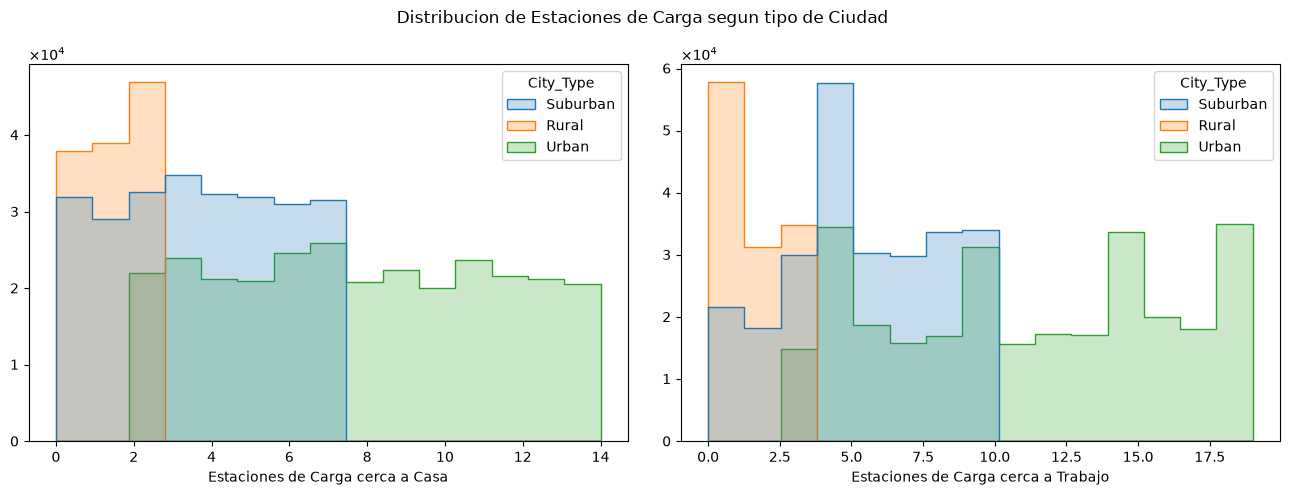

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(13,5))

sns.histplot(x=df['Charging_Stations_Near_Home'], hue=df['City_Type'], bins=15, ax=ax[0], color='olivedrab', element='step', common_norm=False)
ax[0].yaxis.set_major_formatter(formatter)
ax[0].set_ylabel("")
ax[0].set_xlabel("Estaciones de Carga cerca a Casa")

sns.histplot(x=df['Charging_Stations_Near_Work'], bins=15, hue=df['City_Type'],ax=ax[1], color='skyblue', element='step', common_norm=False)
ax[1].yaxis.set_major_formatter(formatter)
ax[1].set_ylabel(" ")
ax[1].set_xlabel("Estaciones de Carga cerca a Trabajo")

fig.suptitle("Distribucion de Estaciones de Carga segun tipo de Ciudad ")
plt.tight_layout()
plt.show()

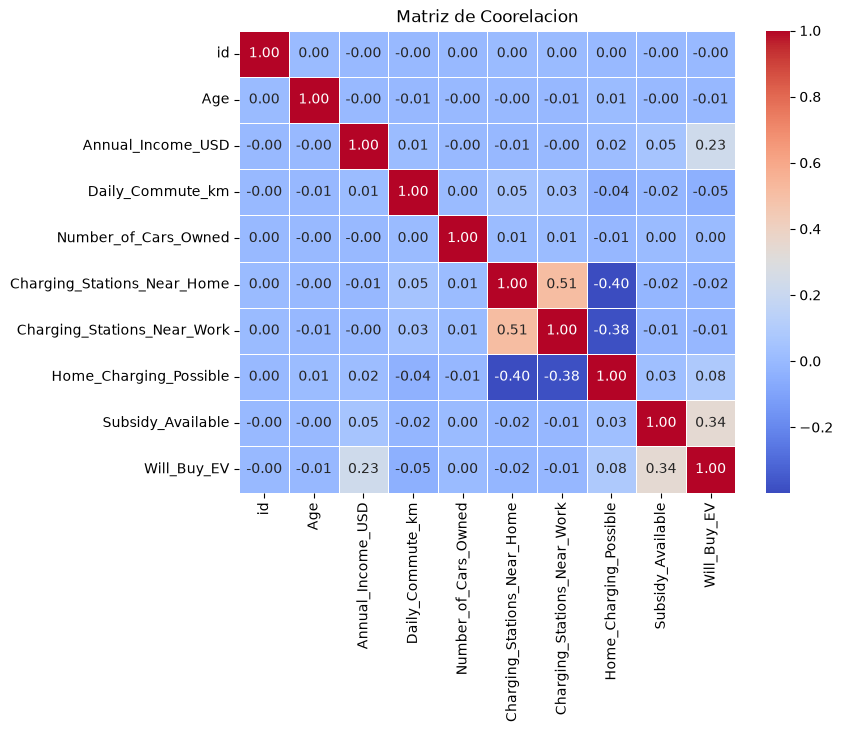

In [23]:
corr_df = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Matriz de Coorelacion")
plt.show()